In [2]:
pip install numpy pandas matplotlib seaborn scipy scikit-learn torch torchinfo

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.4/363.4 MB 4.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.8/13.8 MB 55.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.6/24.6 MB 51.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 883.7/883.7 kB 43.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 664.8/664.8 MB 2.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 211.5/211.5 MB 6.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 MB 11.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 127.9/127.9 MB 7.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 207.5/207.5 MB 5.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 21.1/21.1 MB 88.5 MB/s eta 0:00:00
  Attempting uninstall: nvidia-nvjitlink-cu12
    Found existing installation: nvidia-nvjitlink-cu12 12.5.82
    Uninstalling nvidia-nvjitlink-cu12-12.5.82:
      Successfully uninstalled nvidia-nvjitlin

In [4]:
# Standard Libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

# Scikit-learn Libraries
from sklearn.datasets import fetch_covtype
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, log_loss
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# PyTorch Core
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch import Tensor
from torch.autograd import Function
from torch.utils.checkpoint import checkpoint

# PyTorch Utilities
import torch.utils.benchmark as benchmark
import torch._dynamo
from torch.optim import Optimizer

# PyTorch Model Utilities
from torchinfo import summary
import gc


In [5]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device)

cuda


In [6]:
df = sns.load_dataset('diamonds')
df = df[['carat', 'depth', 'table', 'price', 'x', 'y', 'z', 'cut']]

df['cut'] = (df['cut'] == 'Ideal').astype(int)

X = df.drop('cut', axis=1)
y = df['cut']

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42)

X_train_tensor = torch.tensor(X_train, dtype=torch.float32).to(device)
y_train_tensor = torch.tensor(y_train.values, dtype=torch.long).to(device)
X_test_tensor = torch.tensor(X_test, dtype=torch.float32).to(device)
y_test_tensor = torch.tensor(y_test.values, dtype=torch.long).to(device)

print(X.shape)
print(y.shape)

ideal_percentage = df['cut'].mean() * 100
print(f"Percentage of diamonds with 'Ideal' cut: {ideal_percentage:.2f}%")

model = LogisticRegression(penalty='l2', C=0.001, max_iter=10000)
model.fit(X_train, y_train)

y_pred = model.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)

y_pred_proba = model.predict_proba(X_test)
loss = log_loss(y_test, y_pred_proba)

print(f"Test Accuracy: {accuracy * 100:.2f}%")
print("Classification Report:")
print(classification_report(y_test, y_pred, target_names=['Not Ideal', 'Ideal']))
print(model.coef_)
print(f"Log Loss: {loss:.6f}")

(53940, 7)
(53940,)
Percentage of diamonds with 'Ideal' cut: 39.95%
Test Accuracy: 79.30%
Classification Report:
              precision    recall  f1-score   support

   Not Ideal       0.82      0.85      0.83      6496
       Ideal       0.75      0.71      0.73      4292

    accuracy                           0.79     10788
   macro avg       0.79      0.78      0.78     10788
weighted avg       0.79      0.79      0.79     10788

[[-0.15688782 -0.46189194 -1.57368125  0.22509094 -0.08309788 -0.03167662
  -0.08671039]]
Log Loss: 0.451068


In [7]:
def train(model, criterion, optimizers, epochs):
    print(summary(model, input_data=X_train_tensor))

    # torch.set_printoptions(threshold=float('inf'))
    # for name, param in model.named_parameters():
    #     print(name)
    #     print(param)

    # @torch._dynamo.explain
    # def run_model(x):
    #     return model(x)

    # run_model(X_train_tensor) # type: ignore

    best_test_loss = float('inf')

    train_losses = []
    test_losses = []

    if torch.cuda.is_available():
        torch.cuda.empty_cache()
        torch.cuda.reset_peak_memory_stats()
        torch.cuda.synchronize()

    schedulers = [
        torch.optim.lr_scheduler.LinearLR(opt, start_factor=1.0, end_factor=0.05, total_iters=epochs)
        for opt in optimizers
    ]

    for epoch in range(1, epochs + 1):
        model.train()
        for opt in optimizers:
            opt.zero_grad()

        train_outputs = model(X_train_tensor)
        train_loss = criterion(train_outputs, y_train_tensor)
        train_loss.backward()

        for opt in optimizers:
            opt.step()

        model.eval()
        with torch.no_grad():
            test_outputs = model(X_test_tensor)
            test_loss = criterion(test_outputs, y_test_tensor)
            test_predictions = torch.argmax(test_outputs, dim=1)
            test_accuracy = (test_predictions == y_test_tensor).sum().item() / y_test_tensor.size(0)

        train_losses.append(train_loss.item())
        test_losses.append(test_loss.item())

        if test_loss.item() < best_test_loss:
            best_test_loss = test_loss.item()

        for scheduler in schedulers:
            scheduler.step()

        if epoch % 100 == 0:
            print(f"Epoch {epoch}/{epochs}, Train Loss: {train_loss.item():.8f}, Test Loss: {test_loss.item():.8f}, Test Accuracy: {test_accuracy:.4f}")

    if torch.cuda.is_available():
        gc.collect()
        torch.cuda.empty_cache()
        torch.cuda.synchronize()

        print(f"[GPU] Peak memory allocated: {torch.cuda.max_memory_allocated() / 1024 ** 2:.2f} MB")
        print(f"[GPU] Peak memory reserved: {torch.cuda.max_memory_reserved() / 1024 ** 2:.2f} MB")

    print()
    print(f"Lowest Test Loss: {best_test_loss:.8f}")

    plt.figure(figsize=(10, 5))
    plt.plot(train_losses, label='Train Loss')
    plt.plot(test_losses, label='Test Loss')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.title('Training and Test Loss Over Epochs')
    plt.legend()
    plt.grid(True)
    plt.show()

In [8]:
class ReLU_NN(nn.Module):
    def __init__(self, n, num_layers=4):
        super().__init__()
        self.initial = nn.Linear(n, n * 4)

        self.lns = nn.ModuleList()
        self.linears = nn.ModuleList()
        for i in range(num_layers):
            if i % 2 == 0:
                self.lns.append(nn.LayerNorm(n * 4))
                self.linears.append(nn.Linear(n * 4, n))
            elif i != num_layers - 1:
                self.lns.append(nn.LayerNorm(n))
                self.linears.append(nn.Linear(n, n * 4))
            else:
                self.lns.append(nn.LayerNorm(n))
                self.linears.append(nn.Linear(n, 2))

                with torch.no_grad():
                    nn.init.zeros_(self.linears[-1].weight)
                    nn.init.zeros_(self.linears[-1].bias)

    def _checkpoint_block(self, x, linear, ln):
        def custom_forward(*inputs):
            x = inputs[0]
            return linear(F.relu(ln(x)))
        return checkpoint(custom_forward, x)

    def forward(self, x):
        x = self.initial(x)

        for linear, ln in zip(self.linears, self.lns):
            x = self._checkpoint_block(x, linear, ln)

        return x

In [9]:
class CReLUFunction(Function):
    @staticmethod
    def forward(ctx, input):
        ctx.save_for_backward(input)
        pos = torch.relu(input)
        neg = torch.relu(-input)
        return torch.cat((pos, neg), dim=1)

    @staticmethod
    def backward(ctx, grad_output):
        input, = ctx.saved_tensors

        channels = input.shape[1]
        grad_pos = grad_output[:, :channels]
        grad_neg = grad_output[:, channels:]

        grad_input = grad_pos * (input > 0).float() - grad_neg * (input < 0).float()

        return grad_input

class CReLU(nn.Module):
    def forward(self, x):
        return CReLUFunction.apply(x)

class CReLU_NN(nn.Module):
    def __init__(self, n, num_layers=12):
        super().__init__()
        self.activation = CReLU()
        self.initial = nn.Linear(n * 2, n * 2)

        self.lns = nn.ModuleList()
        self.linears = nn.ModuleList()
        for i in range(num_layers):
            if i % 2 == 0:
                self.lns.append(nn.LayerNorm(n * 2))
                self.linears.append(nn.Linear(n * 4, n))
            elif i != num_layers - 1:
                self.lns.append(nn.LayerNorm(n))
                self.linears.append(nn.Linear(n * 2, n * 2))
            else:
                self.lns.append(nn.LayerNorm(n))
                self.linears.append(nn.Linear(n * 2, 2))

                with torch.no_grad():
                    nn.init.zeros_(self.linears[-1].weight)
                    nn.init.zeros_(self.linears[-1].bias)

    def _checkpoint_block(self, x, linear, ln):
        def custom_forward(*inputs):
            x = inputs[0]
            return linear(self.activation(ln(x)))
        return checkpoint(custom_forward, x)

    def forward(self, x):
        x = self.initial(self.activation(x))

        for linear, ln in zip(self.linears, self.lns):
            x = self._checkpoint_block(x, linear, ln)

        return x

/usr/local/lib/python3.11/dist-packages/torch/_dynamo/eval_frame.py:745: UserWarning: torch.utils.checkpoint: the use_reentrant parameter should be passed explicitly. In version 2.5 we will raise an exception if use_reentrant is not passed. use_reentrant=False is recommended, but if you need to preserve the current default behavior, you can pass use_reentrant=True. Refer to docs for more details on the differences between the two variants.
  return fn(*args, **kwargs)
/usr/local/lib/python3.11/dist-packages/torch/utils/checkpoint.py:87: UserWarning: None of the inputs have requires_grad=True. Gradients will be None
  warnings.warn(


Layer (type:depth-idx)                   Output Shape              Param #
ReLU_NN                                  [43152, 2]                --
├─Linear: 1-1                            [43152, 28]               224
├─ModuleList: 1-8                        --                        (recursive)
│    └─LayerNorm: 2-1                    [43152, 28]               56
├─ModuleList: 1-9                        --                        (recursive)
│    └─Linear: 2-2                       [43152, 7]                203
├─ModuleList: 1-8                        --                        (recursive)
│    └─LayerNorm: 2-3                    [43152, 7]                14
├─ModuleList: 1-9                        --                        (recursive)
│    └─Linear: 2-4                       [43152, 28]               224
├─ModuleList: 1-8                        --                        (recursive)
│    └─LayerNorm: 2-5                    [43152, 28]               56
├─ModuleList: 1-9                    

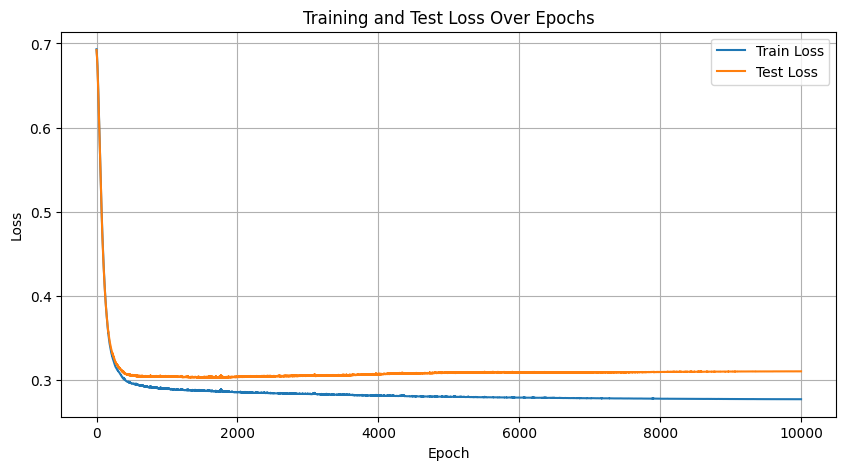

In [10]:
model = ReLU_NN(n=X.shape[1]).to(device)
criterion = nn.CrossEntropyLoss()

optimizers = [optim.AdamW(model.parameters(), weight_decay=0.0)]
train(model, criterion, optimizers, 10000)

/usr/local/lib/python3.11/dist-packages/torch/_dynamo/eval_frame.py:745: UserWarning: torch.utils.checkpoint: the use_reentrant parameter should be passed explicitly. In version 2.5 we will raise an exception if use_reentrant is not passed. use_reentrant=False is recommended, but if you need to preserve the current default behavior, you can pass use_reentrant=True. Refer to docs for more details on the differences between the two variants.
  return fn(*args, **kwargs)
/usr/local/lib/python3.11/dist-packages/torch/utils/checkpoint.py:87: UserWarning: None of the inputs have requires_grad=True. Gradients will be None
  warnings.warn(


Layer (type:depth-idx)                   Output Shape              Param #
ReLU_NN                                  [43152, 2]                --
├─Linear: 1-1                            [43152, 28]               224
├─ModuleList: 1-24                       --                        (recursive)
│    └─LayerNorm: 2-1                    [43152, 28]               56
├─ModuleList: 1-25                       --                        (recursive)
│    └─Linear: 2-2                       [43152, 7]                203
├─ModuleList: 1-24                       --                        (recursive)
│    └─LayerNorm: 2-3                    [43152, 7]                14
├─ModuleList: 1-25                       --                        (recursive)
│    └─Linear: 2-4                       [43152, 28]               224
├─ModuleList: 1-24                       --                        (recursive)
│    └─LayerNorm: 2-5                    [43152, 28]               56
├─ModuleList: 1-25                   

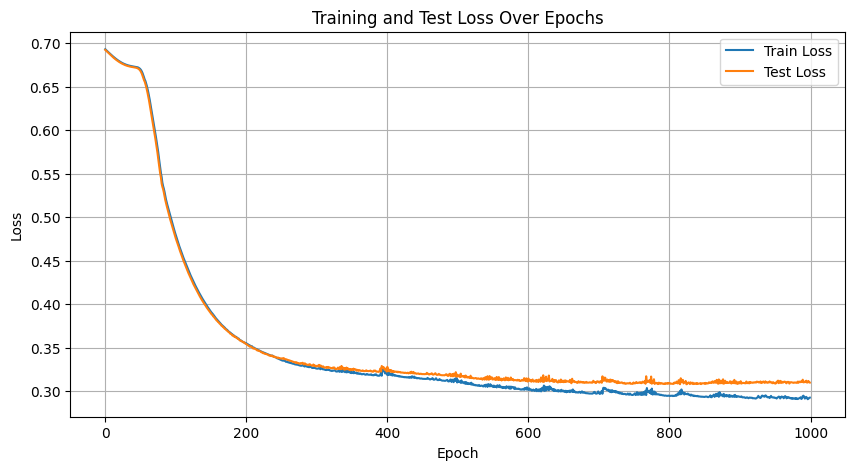

In [ ]:
model = ReLU_NN(n=X.shape[1]).to(device)
criterion = nn.CrossEntropyLoss()

optimizers = [optim.AdamW(model.parameters(), weight_decay=0.0)]
train(model, criterion, optimizers, 1000)

/usr/local/lib/python3.11/dist-packages/torch/_dynamo/eval_frame.py:745: UserWarning: torch.utils.checkpoint: the use_reentrant parameter should be passed explicitly. In version 2.5 we will raise an exception if use_reentrant is not passed. use_reentrant=False is recommended, but if you need to preserve the current default behavior, you can pass use_reentrant=True. Refer to docs for more details on the differences between the two variants.
  return fn(*args, **kwargs)
/usr/local/lib/python3.11/dist-packages/torch/utils/checkpoint.py:87: UserWarning: None of the inputs have requires_grad=True. Gradients will be None
  warnings.warn(


Layer (type:depth-idx)                   Output Shape              Param #
CReLU_NN                                 [43152, 2]                --
├─CReLU: 1-1                             [43152, 14]               --
├─Linear: 1-2                            [43152, 14]               210
├─ModuleList: 1-36                       --                        (recursive)
│    └─LayerNorm: 2-1                    [43152, 14]               28
├─CReLU: 1-4                             [43152, 28]               --
├─ModuleList: 1-38                       --                        (recursive)
│    └─Linear: 2-2                       [43152, 7]                203
├─ModuleList: 1-36                       --                        (recursive)
│    └─LayerNorm: 2-3                    [43152, 7]                14
├─CReLU: 1-7                             [43152, 14]               --
├─ModuleList: 1-38                       --                        (recursive)
│    └─Linear: 2-4                       [43152

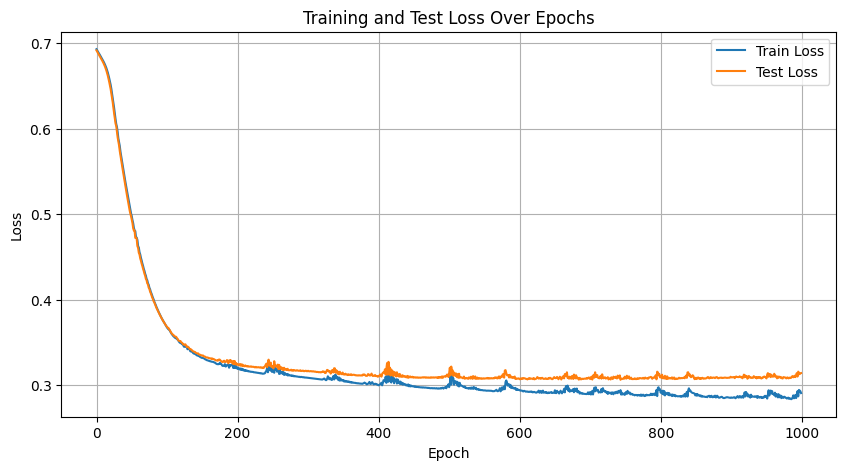

In [ ]:
model = CReLU_NN(n=X.shape[1]).to(device)
criterion = nn.CrossEntropyLoss()

optimizers = [optim.AdamW(model.parameters(), weight_decay=0.0)]
train(model, criterion, optimizers, 1000)

/usr/local/lib/python3.11/dist-packages/torch/_dynamo/eval_frame.py:745: UserWarning: torch.utils.checkpoint: the use_reentrant parameter should be passed explicitly. In version 2.5 we will raise an exception if use_reentrant is not passed. use_reentrant=False is recommended, but if you need to preserve the current default behavior, you can pass use_reentrant=True. Refer to docs for more details on the differences between the two variants.
  return fn(*args, **kwargs)
/usr/local/lib/python3.11/dist-packages/torch/utils/checkpoint.py:87: UserWarning: None of the inputs have requires_grad=True. Gradients will be None
  warnings.warn(


Layer (type:depth-idx)                   Output Shape              Param #
ReLU_NN                                  [43152, 2]                --
├─Linear: 1-1                            [43152, 28]               224
├─ModuleList: 1-24                       --                        (recursive)
│    └─LayerNorm: 2-1                    [43152, 28]               56
├─ModuleList: 1-25                       --                        (recursive)
│    └─Linear: 2-2                       [43152, 7]                203
├─ModuleList: 1-24                       --                        (recursive)
│    └─LayerNorm: 2-3                    [43152, 7]                14
├─ModuleList: 1-25                       --                        (recursive)
│    └─Linear: 2-4                       [43152, 28]               224
├─ModuleList: 1-24                       --                        (recursive)
│    └─LayerNorm: 2-5                    [43152, 28]               56
├─ModuleList: 1-25                   

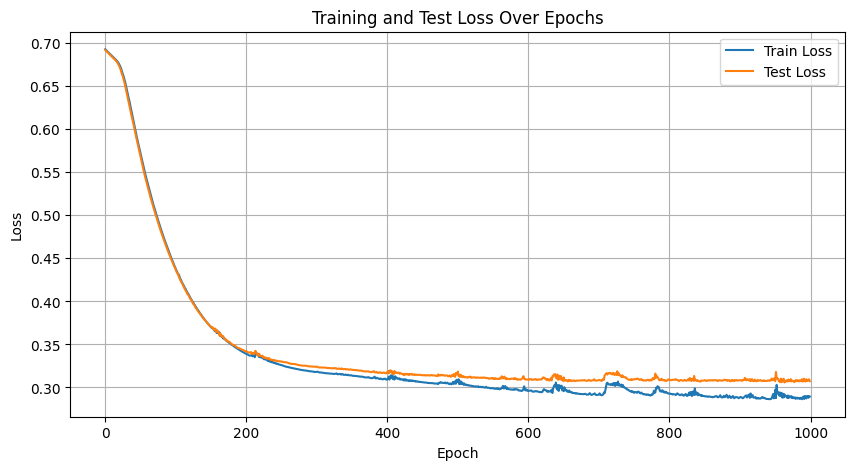

In [ ]:
model = ReLU_NN(n=X.shape[1]).to(device)
criterion = nn.CrossEntropyLoss()

optimizers = [optim.AdamW(model.parameters(), weight_decay=0.0)]
train(model, criterion, optimizers, 1000)

Layer (type:depth-idx)                   Output Shape              Param #
CReLU_NN                                 [43152, 2]                --
├─CReLU: 1-1                             [43152, 14]               --
├─Linear: 1-2                            [43152, 14]               210
├─ModuleList: 1-36                       --                        (recursive)
│    └─LayerNorm: 2-1                    [43152, 14]               28
├─CReLU: 1-4                             [43152, 28]               --
├─ModuleList: 1-38                       --                        (recursive)
│    └─Linear: 2-2                       [43152, 7]                203
├─ModuleList: 1-36                       --                        (recursive)
│    └─LayerNorm: 2-3                    [43152, 7]                14
├─CReLU: 1-7                             [43152, 14]               --
├─ModuleList: 1-38                       --                        (recursive)
│    └─Linear: 2-4                       [43152

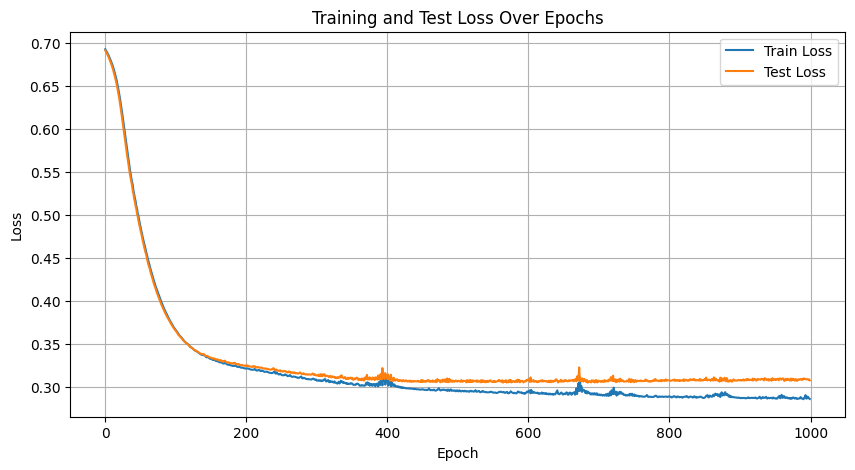

In [ ]:
model = CReLU_NN(n=X.shape[1]).to(device)
criterion = nn.CrossEntropyLoss()

optimizers = [optim.AdamW(model.parameters(), weight_decay=0.0)]
train(model, criterion, optimizers, 1000)

Layer (type:depth-idx)                   Output Shape              Param #
ReLU_NN                                  [43152, 2]                --
├─Linear: 1-1                            [43152, 28]               224
├─ModuleList: 1-24                       --                        (recursive)
│    └─LayerNorm: 2-1                    [43152, 28]               56
├─ModuleList: 1-25                       --                        (recursive)
│    └─Linear: 2-2                       [43152, 7]                203
├─ModuleList: 1-24                       --                        (recursive)
│    └─LayerNorm: 2-3                    [43152, 7]                14
├─ModuleList: 1-25                       --                        (recursive)
│    └─Linear: 2-4                       [43152, 28]               224
├─ModuleList: 1-24                       --                        (recursive)
│    └─LayerNorm: 2-5                    [43152, 28]               56
├─ModuleList: 1-25                   

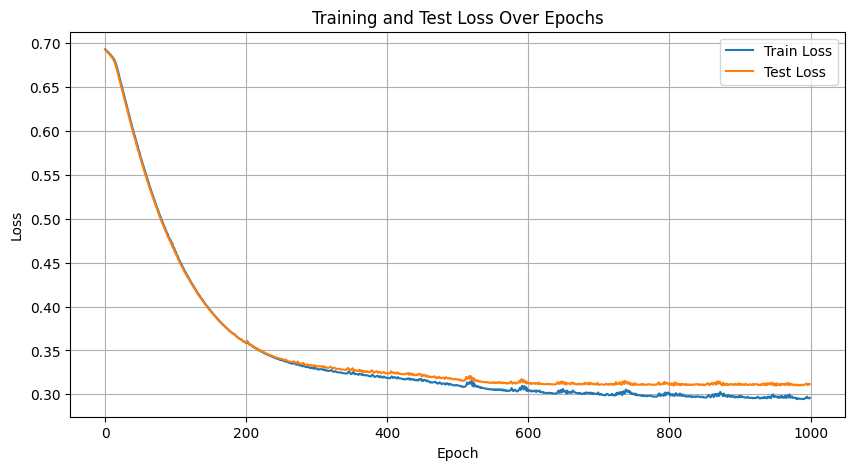

In [ ]:
model = ReLU_NN(n=X.shape[1]).to(device)
criterion = nn.CrossEntropyLoss()

optimizers = [optim.AdamW(model.parameters(), weight_decay=0.0)]
train(model, criterion, optimizers, 1000)

Layer (type:depth-idx)                   Output Shape              Param #
CReLU_NN                                 [43152, 2]                --
├─CReLU: 1-1                             [43152, 14]               --
├─Linear: 1-2                            [43152, 14]               210
├─ModuleList: 1-36                       --                        (recursive)
│    └─LayerNorm: 2-1                    [43152, 14]               28
├─CReLU: 1-4                             [43152, 28]               --
├─ModuleList: 1-38                       --                        (recursive)
│    └─Linear: 2-2                       [43152, 7]                203
├─ModuleList: 1-36                       --                        (recursive)
│    └─LayerNorm: 2-3                    [43152, 7]                14
├─CReLU: 1-7                             [43152, 14]               --
├─ModuleList: 1-38                       --                        (recursive)
│    └─Linear: 2-4                       [43152

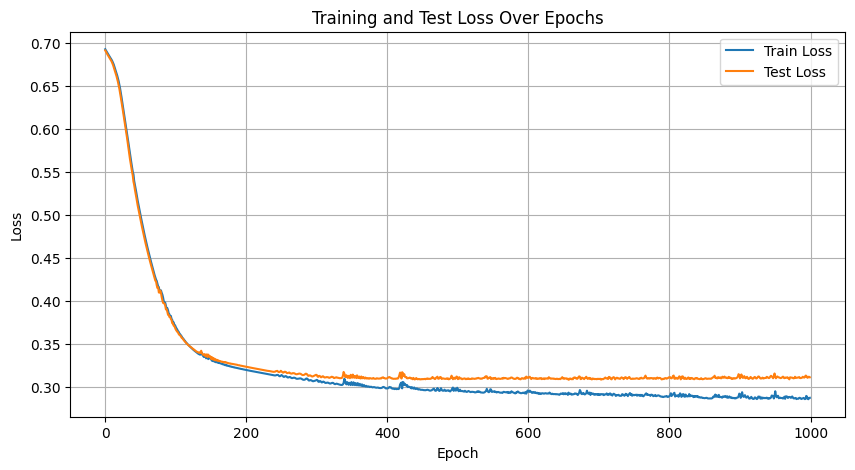

In [ ]:
model = CReLU_NN(n=X.shape[1]).to(device)
criterion = nn.CrossEntropyLoss()

optimizers = [optim.AdamW(model.parameters(), weight_decay=0.0)]
train(model, criterion, optimizers, 1000)